# Credit Card Fraud Detection Using Machine Learning

This project builds a fraud detection pipeline using Python, PySpark, SMOTE, and Random Forest classification to identify fraudulent credit card transactions in a highly imbalanced dataset.

In [2]:
%pip install pyspark imbalanced-learn seaborn

In [3]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [4]:
import subprocess

subprocess.run(["java", "-version"])

CompletedProcess(args=['java', '-version'], returncode=0)

In [5]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
from matplotlib import pyplot as plt
import seaborn as sns

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnull, when, count, mean
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.functions import vector_to_array

# Machine learning
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Credit Card Fraud Detection") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

file_path = "C:/Users/tsamv/Downloads/MS Projects/Python - project/creditcard.csv"

df = spark.read.csv(file_path, header=True, inferSchema=True)

df.show(5)
df.printSchema()

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|                V22|     

In [7]:
# Checking for missing values in each column
missing_data = df.select([count(when(isnull(c), c)).alias(c) for c in df.columns])
missing_data.show()

+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



In [8]:
# Drop rows with missing values
df_cleaned = df.dropna()

# Calculate the mean of each column and fill missing values
df = df.fillna(df.agg(*(mean(c).alias(c) for c in df.columns)).first().asDict())


In [9]:
# Assembling the features into a single vector column (required for normalization)
assembler = VectorAssembler(inputCols=["Amount", "Time"], outputCol="features_temp")
df_assembled = assembler.transform(df_cleaned)

# Import MinMaxScaler
from pyspark.ml.feature import MinMaxScaler

# Applying MinMaxScaler for normalization
scaler = MinMaxScaler(inputCol="features_temp", outputCol="features_scaled")
scaler_model = scaler.fit(df_assembled)
df_normalized = scaler_model.transform(df_assembled)

# Split normalized features back to original columns
df_normalized = df_normalized.withColumn("Amount_Scaled", vector_to_array("features_scaled")[0])
df_normalized = df_normalized.withColumn("Time_Scaled", vector_to_array("features_scaled")[1])

# Drop unnecessary columns
columns_to_drop = [col for col in ["features_temp", "features_scaled", "Amount", "Time"] if col in df_normalized.columns]
df_final = df_normalized.drop(*columns_to_drop)
df_normalized.show(5)
df_final.show(5)

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+-------------+--------------------+--------------------+--------------------+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|        

In [10]:
# Feature Engineering on 'Time' - create new features like hour of the day
df_final = df_final.withColumn("Hour", (col("Time_Scaled") % 86400) / 3600)
df_final = df_final.withColumn("Minute", (col("Time_Scaled") % 3600) / 60)
df_final = df_final.withColumn("Second", col("Time_Scaled") % 60)

df_final.show(5)

+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+
|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V

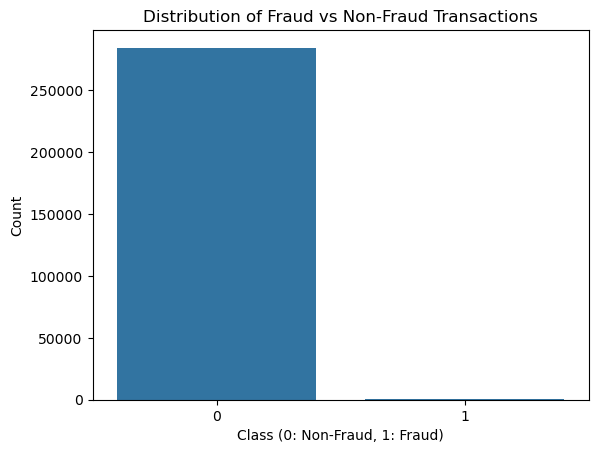

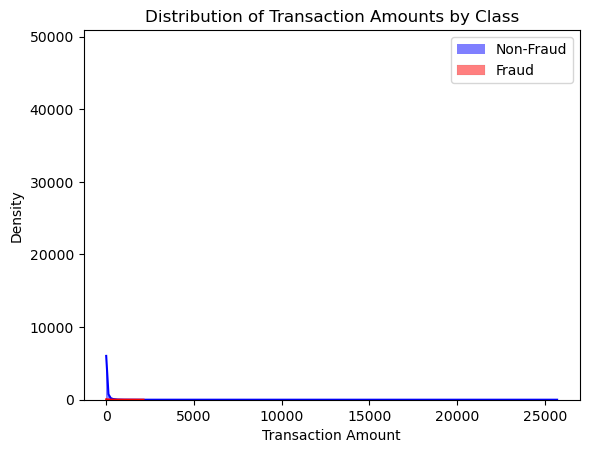

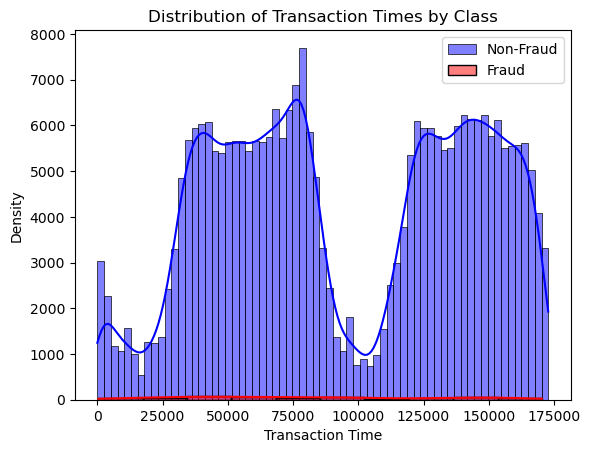

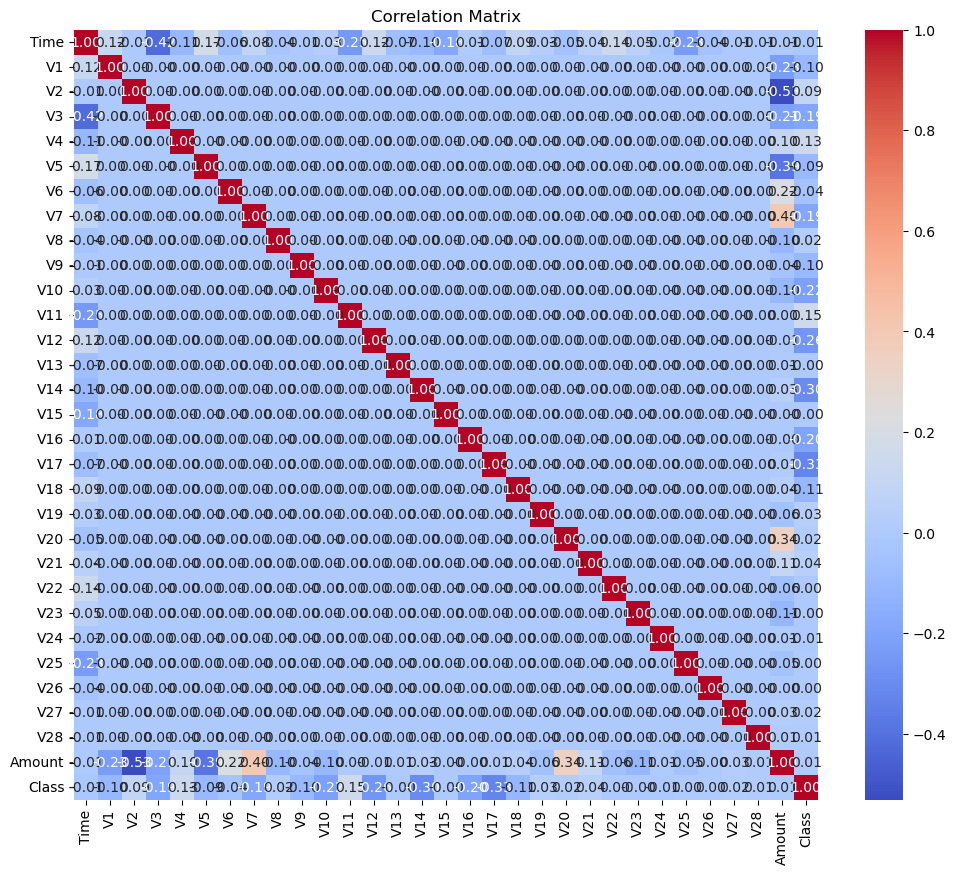

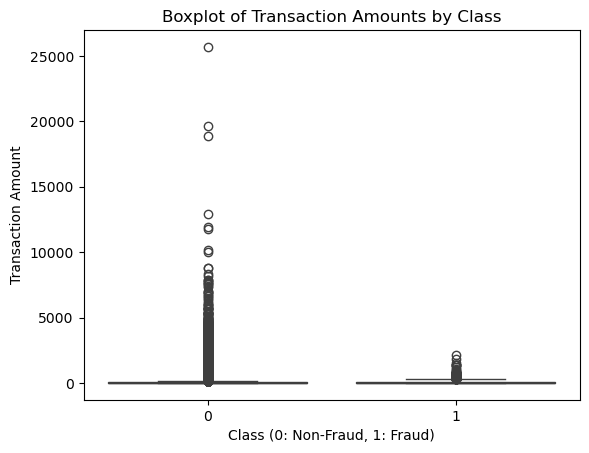

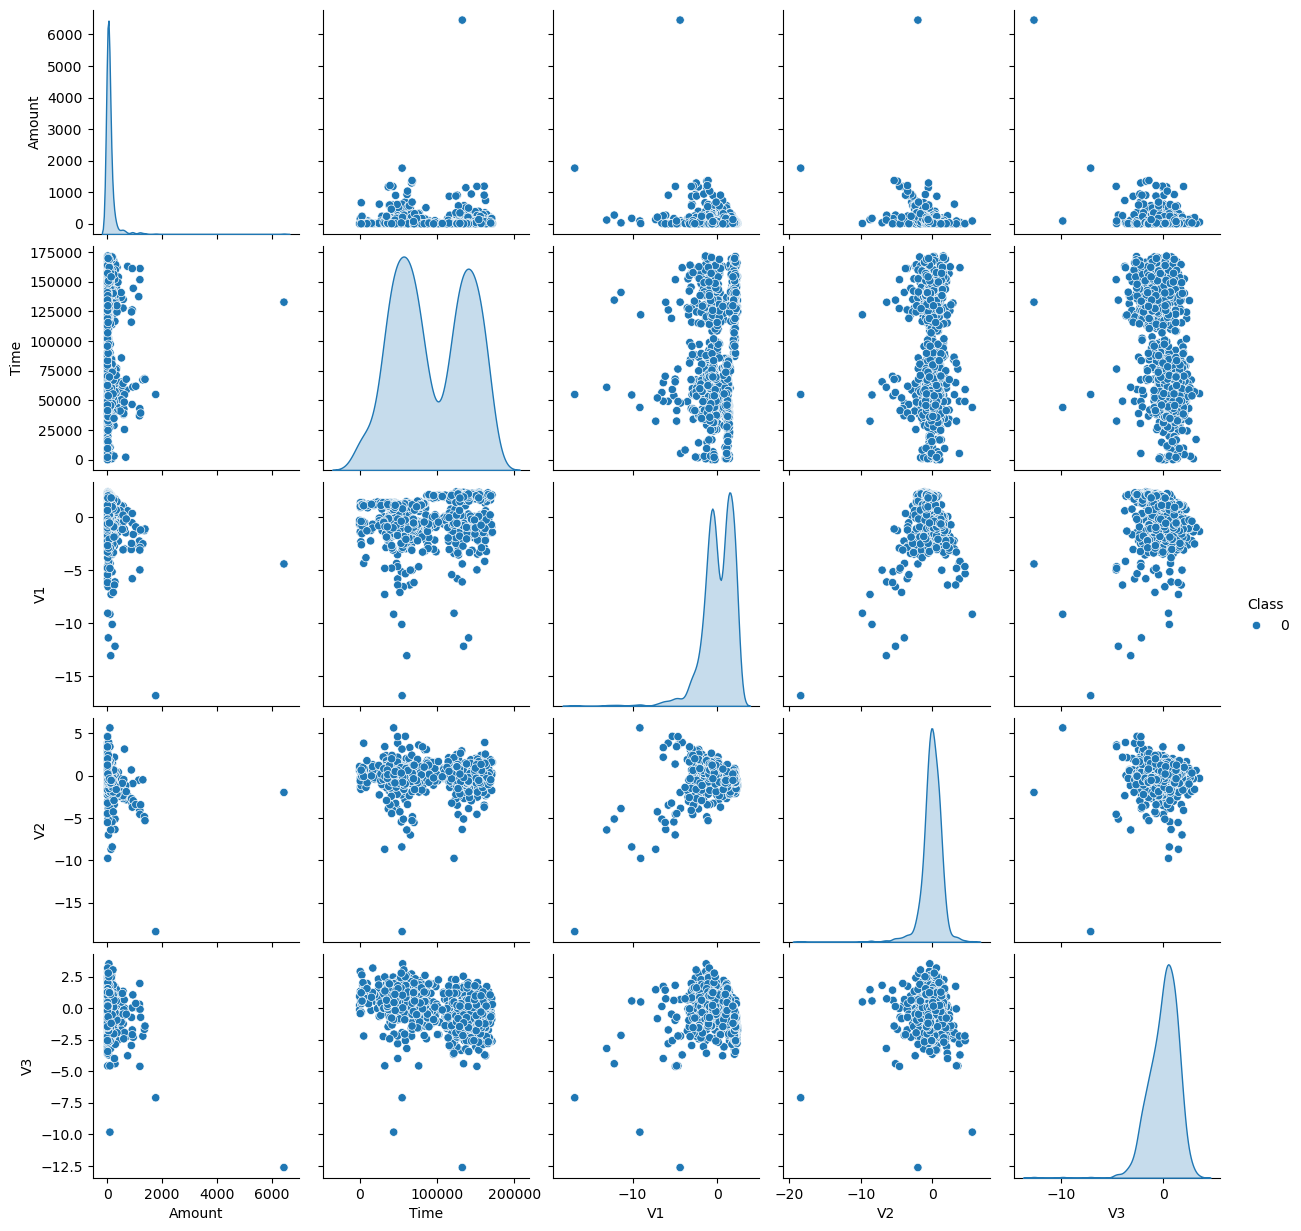

In [11]:
# Converting PySpark DataFrame to Pandas DataFrame for visualization
df_pandas = df.toPandas()

# 1. Distribution of the target class (fraud vs non-fraud)
sns.countplot(x="Class", data=df_pandas)
plt.title("Distribution of Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Count")
plt.show()

# 2. Distribution of 'Amount' and 'Time' in Fraudulent vs Non-Fraudulent transactions
sns.histplot(df_pandas[df_pandas['Class'] == 0]['Amount'], color='blue', label='Non-Fraud', kde=True)
sns.histplot(df_pandas[df_pandas['Class'] == 1]['Amount'], color='red', label='Fraud', kde=True)
plt.title("Distribution of Transaction Amounts by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

sns.histplot(df_pandas[df_pandas['Class'] == 0]['Time'], color='blue', label='Non-Fraud', kde=True)
sns.histplot(df_pandas[df_pandas['Class'] == 1]['Time'], color='red', label='Fraud', kde=True)
plt.title("Distribution of Transaction Times by Class")
plt.xlabel("Transaction Time")
plt.ylabel("Density")
plt.legend()
plt.show()

# 3. Correlation Matrix
corr_matrix = df_pandas.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 4. Boxplot to see the outliers in 'Amount' feature by class
sns.boxplot(x="Class", y="Amount", data=df_pandas)
plt.title("Boxplot of Transaction Amounts by Class")
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

# 5. Pairplot for visualizing the relationships between features
sns.pairplot(df_pandas.sample(1000), hue="Class", vars=["Amount", "Time", "V1", "V2", "V3"])
plt.show()

In [12]:
# Convert Spark DataFrame to Pandas DataFrame for further analysis
processed_data = df_final.toPandas()
X = processed_data.drop(['Class'], axis=1)
y = processed_data['Class']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [13]:
# Apply SMOTE to handle class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())


Class distribution after SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64


In [14]:
# Train a Random Forest classifier

from sklearn.metrics import roc_auc_score, classification_report

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_smote, y_train_smote)

# Predict probabilities for ROC-AUC
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc}")

# Classification Report
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))


ROC-AUC: 0.9509346734623715
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.76      0.82       148

    accuracy                           1.00     85443
   macro avg       0.94      0.88      0.91     85443
weighted avg       1.00      1.00      1.00     85443



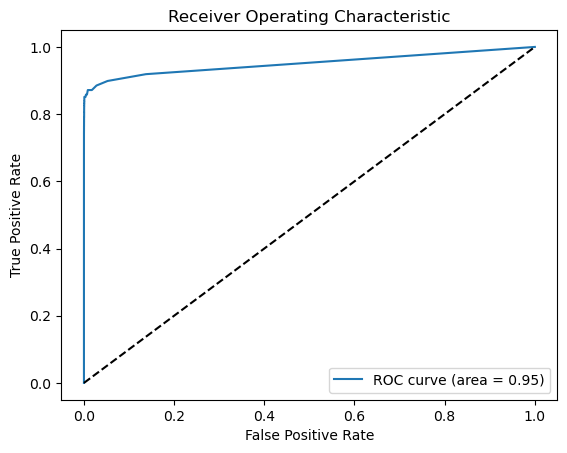

In [15]:
# Plot the ROC curve


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


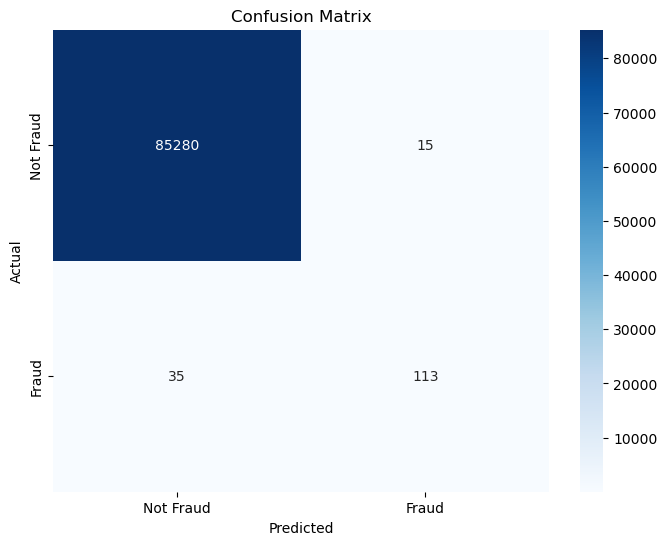

C:\Users\tsamv\AppData\Local\Temp\ipykernel_32000\1733092166.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Category", y="Count", palette="viridis")


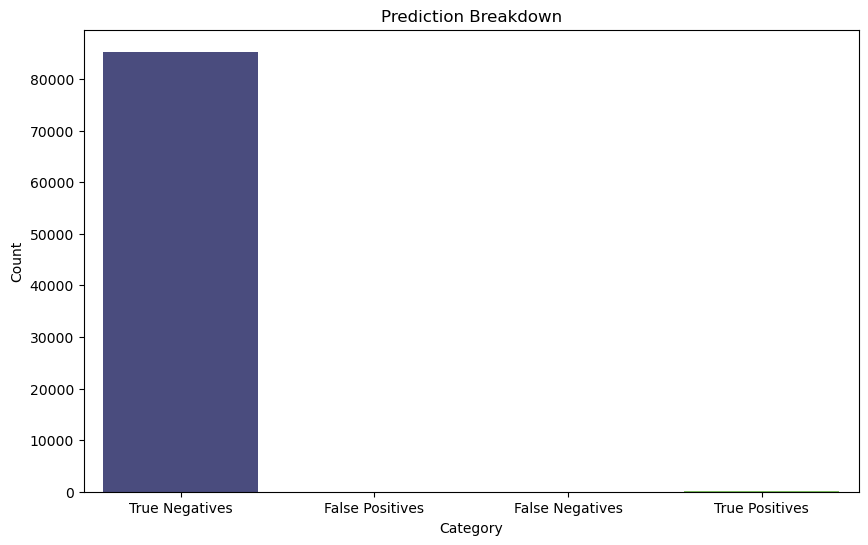

In [17]:
# Generate the confusion matrix
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Bar plot for prediction categories
labels = ["True Negatives", "False Positives", "False Negatives", "True Positives"]
values = [conf_matrix[0, 0], conf_matrix[0, 1], conf_matrix[1, 0], conf_matrix[1, 1]]

# Create a DataFrame for the barplot
data = pd.DataFrame({"Category": labels, "Count": values})

plt.figure(figsize=(10, 6))
sns.barplot(data=data, x="Category", y="Count", palette="viridis")
plt.title("Prediction Breakdown")
plt.ylabel("Count")
plt.show()

In [19]:
# Select the necessary columns for the features and label
assembler = VectorAssembler(inputCols=['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                                       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
                                       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
                                       'Amount_Scaled', 'Time_Scaled'],
                             outputCol='features')

df_final = assembler.transform(df_final)

# Select the relevant columns
df_final = df_final.select('features', 'Amount_Scaled')

# Split the data into training and testing sets
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)



In [31]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

In [33]:
# Initialize the Linear Regression model
lr = LinearRegression(featuresCol='features', labelCol='Amount_Scaled')

# Fit the model on the training data
lr_model = lr.fit(train_data)

In [35]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Create a parameter grid for hyperparameter tuning
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1, 0.5])
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             .addGrid(lr.maxIter, [50, 100, 200])
             .build())


In [37]:
# CrossValidator for model tuning
crossval = CrossValidator(estimator=lr,
                          estimatorParamMaps=paramGrid,
                          evaluator=RegressionEvaluator(labelCol='Amount_Scaled', metricName='r2'),
                          numFolds=5)

# Perform cross-validation and get the best model
cv_model = crossval.fit(train_data)
best_model = cv_model.bestModel

In [39]:
# Print the best hyperparameters
print(f"Best regParam: {best_model._java_obj.parent().getRegParam()}")
print(f"Best elasticNetParam: {best_model._java_obj.parent().getElasticNetParam()}")
print(f"Best maxIter: {best_model._java_obj.parent().getMaxIter()}")

Best regParam: 0.01
Best elasticNetParam: 0.0
Best maxIter: 50


In [41]:
# Evaluate the model's performance on the test dataset
test_results = best_model.transform(test_data)

# Initialize the evaluator with the label column and prediction column
evaluator = RegressionEvaluator(labelCol='Amount_Scaled', predictionCol='prediction', metricName='rmse')

# Calculate the accuracy (in this case, using Root Mean Squared Error)
rmse = evaluator.evaluate(test_results)

# Print the RMSE (Root Mean Squared Error)
print(f"Root Mean Squared Error (RMSE) on test data: {rmse}")

Root Mean Squared Error (RMSE) on test data: 0.0034602214998619507


In [43]:
# Convert predictions to Pandas for plotting
predictions = best_model.transform(test_data).select('prediction', 'Amount_Scaled').toPandas()


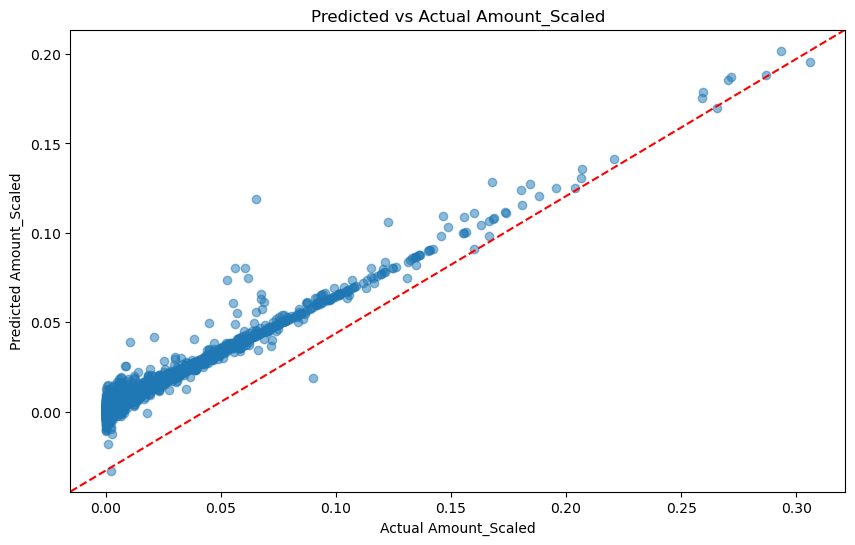

In [45]:
# Plot predicted vs actual
plt.figure(figsize=(10, 6))
plt.scatter(predictions['Amount_Scaled'], predictions['prediction'], alpha=0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', transform=plt.gca().transAxes)
plt.xlabel('Actual Amount_Scaled')
plt.ylabel('Predicted Amount_Scaled')
plt.title('Predicted vs Actual Amount_Scaled')
plt.show()

## Conclusion

The Random Forest classifier successfully detected fraudulent transactions after addressing class imbalance with SMOTE. Model performance was evaluated using ROC-AUC, classification metrics, and confusion matrix analysis. The project demonstrates the application of machine learning techniques for fraud detection in highly imbalanced financial transaction datasets.